# Pneumonia Detection from Chest X-Rays — End-to-End ML Notebook

**Course:** Machine Learning Pipeline — Summative (image / non-tabular extension)
**Author:** Mahlet Tilahun
**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) — Paul Mooney

This notebook covers the full ML lifecycle:
1. Data acquisition
2. Data processing & **detailed preprocessing**
3. Exploratory visualisations — **3 interpreted features**
4. Model creation (MobileNetV2 transfer learning + regularisation, early stopping)
5. Model training
6. Model testing / evaluation — **Accuracy, Loss, Precision, Recall, F1, AUC, confusion matrix**
7. Prediction function
8. Saving the model (`.keras` / `.h5`)
9. Retraining function & trigger

> The reusable logic lives in `src/` (`preprocessing.py`, `model.py`, `prediction.py`).
> This notebook imports and demonstrates it so nothing is duplicated.

## 0 · Setup

Run this from the **project root** with the dataset already downloaded into `data/`
(see `scripts/download_data.py`). Use a **Python 3.10/3.11** environment — TensorFlow 2.15
does not support Python 3.13.


In [1]:
import sys, os, json
# Make the project's src/ importable when running from notebook/
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_style("whitegrid")

import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

Matplotlib is building the font cache; this may take a moment.


TensorFlow: 2.15.0
GPU available: False


## 1 · Data Acquisition

The dataset is the Kaggle *Chest X-Ray Images (Pneumonia)* collection: 5,863 X-ray JPEGs
split into `train/`, `test/`, `val/`, each with `NORMAL/` and `PNEUMONIA/` subfolders.

Download it once with:
```bash
python scripts/download_data.py     # automatic (needs a Kaggle token)
```
or manually (see README). The cell below just checks it is present.

In [2]:
from src.config import TRAIN_DIR, TEST_DIR, VAL_DIR, CLASS_NAMES, IMG_SIZE

for split, d in [("train", TRAIN_DIR), ("test", TEST_DIR), ("val", VAL_DIR)]:
    for cls in CLASS_NAMES:
        p = d / cls
        n = len(list(p.glob("*"))) if p.exists() else 0
        print(f"{split:5s} / {cls:9s}: {n:5d} images")

train / NORMAL   :  1342 images
train / PNEUMONIA:  3876 images
test  / NORMAL   :   235 images
test  / PNEUMONIA:   391 images
val   / NORMAL   :     9 images
val   / PNEUMONIA:     9 images


## 2 · Data Processing & Detailed Preprocessing

Preprocessing steps applied to every image (all implemented in `src/preprocessing.py`):

| Step | What | Why |
|------|------|-----|
| **Resize** | all images → 150×150 | X-rays come in many resolutions; the model needs a fixed input |
| **Channel** | grayscale → RGB (3 ch) | MobileNetV2 was pretrained on 3-channel ImageNet |
| **Rescale** | pixel values ÷ 255 → [0,1] | stabilises gradient descent |
| **Augment (train only)** | rotation, shift, zoom, shear, h-flip | regularisation → less over-fitting on the small NORMAL class |
| **Class weights** | balanced weighting | dataset is ~3× more PNEUMONIA → prevents majority bias |

We build the generators and inspect one augmented batch.


In [3]:
from src.preprocessing import build_generators, compute_class_weights

train_gen, val_gen, test_gen = build_generators()
class_weights = compute_class_weights(train_gen)
print("Class indices:", train_gen.class_indices)
print("Class weights:", class_weights)
print("Train batches:", len(train_gen), "| Val:", len(val_gen), "| Test:", len(test_gen))

Found 5216 images belonging to 2 classes.


Found 16 images belonging to 2 classes.


Found 624 images belonging to 2 classes.


Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}
Train batches: 163 | Val: 1 | Test: 20


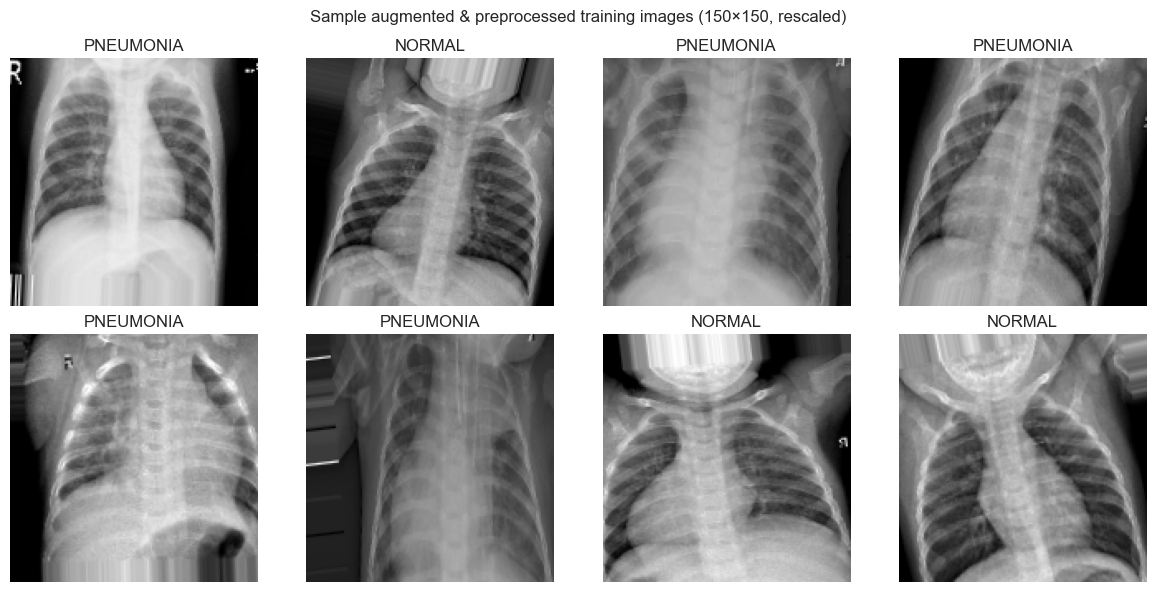

In [4]:
# Visualise one augmented training batch
images, labels = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(CLASS_NAMES[int(labels[i])])
    ax.axis("off")
plt.suptitle("Sample augmented & preprocessed training images (150×150, rescaled)")
plt.tight_layout(); plt.show()

## 3 · Exploratory Visualisations — 3 Interpreted Features

We interpret **three features** of the dataset and what each one tells us.

In [5]:
from src.preprocessing import dataset_summary
summary = dataset_summary(TRAIN_DIR, sample_per_class=120)
summary["class_counts"]

{'NORMAL': 1341, 'PNEUMONIA': 3875}

### Feature 1 — Class distribution (class balance)

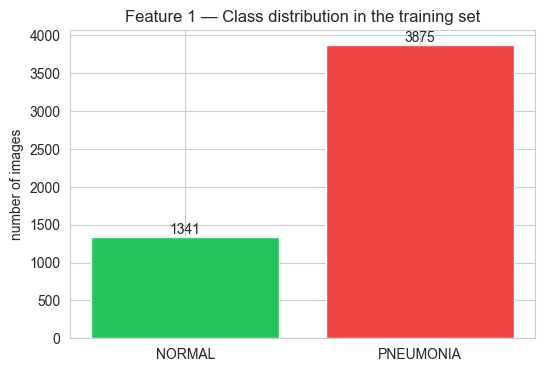

In [6]:
counts = summary["class_counts"]
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=["#22c55e", "#ef4444"])
plt.title("Feature 1 — Class distribution in the training set")
plt.ylabel("number of images")
for i,(k,v) in enumerate(counts.items()):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.show()

The classes are **imbalanced**, with pneumonia images roughly three times as many
as normal ones. A naive model could reach high accuracy by always predicting PNEUMONIA.
We mitigate this with **class weights** and by tracking **recall & F1**, not just accuracy.

### Feature 2 — Mean pixel brightness per class (image intensity)

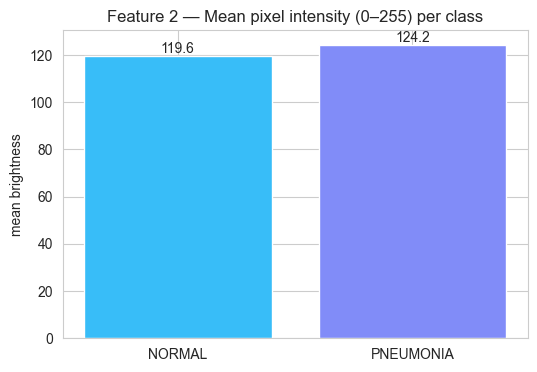

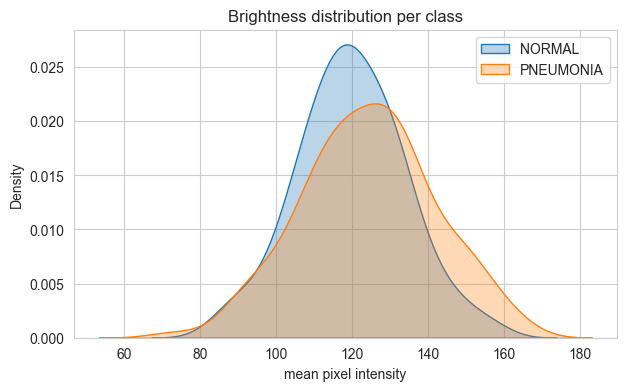

In [7]:
bright = summary["brightness"]
means = {c: bright[c]["mean"] for c in bright}
plt.figure(figsize=(6,4))
plt.bar(means.keys(), means.values(), color=["#38bdf8", "#818cf8"])
plt.title("Feature 2 — Mean pixel intensity (0–255) per class")
plt.ylabel("mean brightness")
for i,(k,v) in enumerate(means.items()):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.show()

# Distribution view
plt.figure(figsize=(7,4))
for c in bright:
    sns.kdeplot(bright[c]["values"], label=c, fill=True, alpha=.3)
plt.title("Brightness distribution per class"); plt.xlabel("mean pixel intensity"); plt.legend(); plt.show()

Pneumonia X-rays tend to contain **denser white opacities** (fluid/infection in the
lungs), which shifts their brightness distribution relative to normal lungs. This is precisely the
visual cue the CNN learns, and the feature is genuinely informative, not noise.

### Feature 3 — Image dimensions (acquisition consistency)

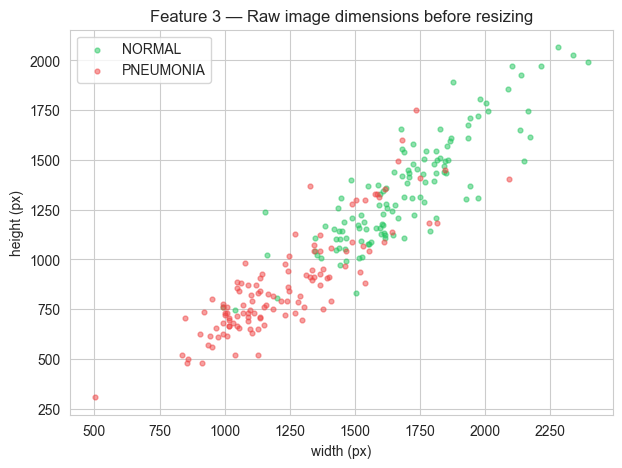

             width       height
count   240.000000   240.000000
mean   1457.662500  1108.429167
std     343.428674   357.024657
min     502.000000   307.000000
25%    1150.000000   798.000000
50%    1466.500000  1097.000000
75%    1692.500000  1367.250000
max    2396.000000  2066.000000


In [8]:
dims = pd.DataFrame(summary["dimensions"])
plt.figure(figsize=(7,5))
for c, col in zip(CLASS_NAMES, ["#22c55e", "#ef4444"]):
    sub = dims[dims["class"] == c]
    plt.scatter(sub["width"], sub["height"], s=12, alpha=.5, label=c, color=col)
plt.xlabel("width (px)"); plt.ylabel("height (px)")
plt.title("Feature 3 — Raw image dimensions before resizing"); plt.legend(); plt.show()
print(dims[["width","height"]].describe())

The raw X-rays are captured at **many different resolutions and aspect ratios**.
Feeding these directly would make the model sensitive to acquisition hardware rather than pathology.
Our preprocessing **resizes every image to 150×150**, removing this variability so the model focuses
on lung content.

## 4 · Model Creation

We use **MobileNetV2 transfer learning** (ImageNet weights, frozen backbone) with a custom head.
Optimisation / regularisation techniques used (rubric "excellent" tier):
- **Pretrained model** (MobileNetV2)
- **Dropout (0.3)** and **L2 weight regularisation** in the head
- **Adam** optimiser with tuned learning rate
- **Data augmentation** (in the generator)
- **Early stopping** + **ReduceLROnPlateau** (next section)


In [9]:
from src.model import build_model
model = build_model(model_type="mobilenet", learning_rate=1e-4)
model.summary()

Model: "pneumonia_mobilenetv2"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 mobilenetv2_1.00_224 (Func  (None, 5, 5, 1280)        2257984   


 tional)                                                         


...

 dense_1 (Dense)             (None, 1)                 65        


Total params: 2340033 (8.93 MB)


Trainable params: 82049 (320.50 KB)


Non-trainable params: 2257984 (8.61 MB)


_________________________________________________________________


## 5 · Model Training

`train_model()` wires in EarlyStopping (patience 4, restores best weights),
ReduceLROnPlateau, and ModelCheckpoint. Reduce `epochs` if running on CPU.


In [10]:
from src.model import train_model
model, history = train_model(model, train_gen, val_gen, epochs=15, class_weights=class_weights)

Epoch 1/15


  1/163 [..............................] - ETA: 21:40 - loss: 0.8598 - accuracy: 0.4375 - precision: 0.9000 - recall: 0.3462 - auc: 0.5705

  2/163 [..............................] - ETA: 2:34 - loss: 0.8553 - accuracy: 0.4219 - precision: 0.8750 - recall: 0.2857 - auc: 0.6007 

  3/163 [..............................] - ETA: 2:54 - loss: 0.8866 - accuracy: 0.4583 - precision: 0.8929 - recall: 0.3378 - auc: 0.6035

  4/163 [..............................] - ETA: 2:49 - loss: 0.8765 - accuracy: 0.4375 - precision: 0.7805 - recall: 0.3368 - auc: 0.5604

...

Restoring model weights from the end of the best epoch: 3.



Epoch 7: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.



Epoch 7: val_loss did not improve from 0.37651


163/163 [==============================] - 176s 1s/step - loss: 0.2554 - accuracy: 0.8972 - precision: 0.9652 - recall: 0.8939 - auc: 0.9635 - val_loss: 0.3917 - val_accuracy: 0.8750 - val_precision: 0.8750 - val_recall: 0.8750 - val_auc: 0.9062 - lr: 3.0000e-05


Epoch 7: early stopping


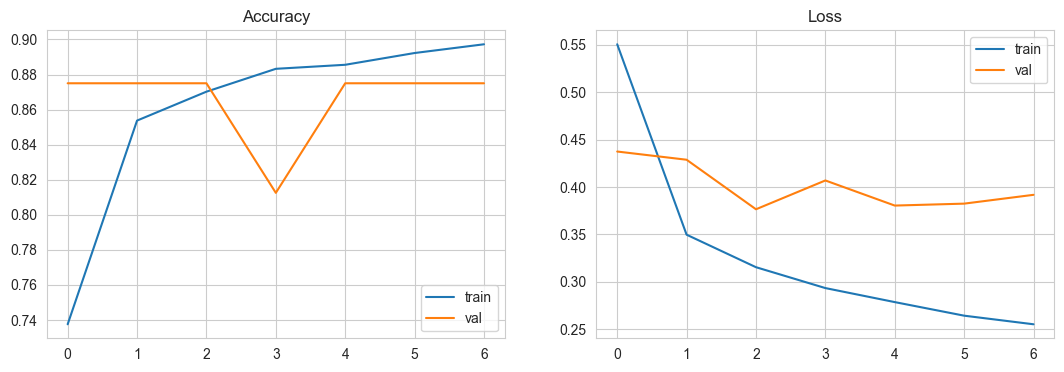

In [11]:
# Training curves
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].legend()
plt.show()

## 6 · Model Testing / Evaluation

We evaluate on the **held-out test set** with the full metric suite the rubric requires:
**Accuracy, Loss, Precision, Recall, F1, AUC**, plus the confusion matrix and a classification report.


In [12]:
from src.model import evaluate_model
metrics = evaluate_model(model, test_gen)
print(json.dumps({k: metrics[k] for k in
      ["accuracy","precision","recall","f1_score","auc","loss","n_test_samples"]}, indent=2))

{
  "accuracy": 0.8461538461538461,
  "precision": 0.8848167539267016,
  "recall": 0.8666666666666667,
  "f1_score": 0.8756476683937824,
  "auc": 0.9287530133683981,
  "loss": 0.334341563703673,
  "n_test_samples": 624
}


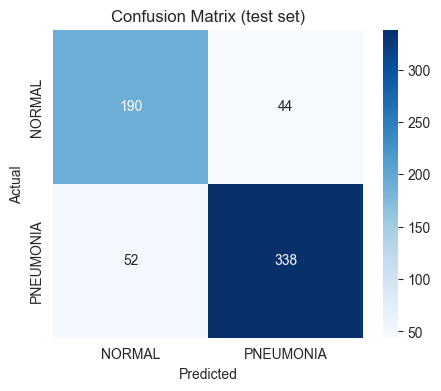

Classification report:


,precision,recall,f1-score,support
NORMAL,0.785124,0.811966,0.798319,234.000000
PNEUMONIA,0.884817,0.866667,0.875648,390.000000
accuracy,0.846154,0.846154,0.846154,0.846154
macro avg,0.834970,0.839316,0.836983,624.000000
weighted avg,0.847432,0.846154,0.846650,624.000000


In [13]:
import numpy as np
cm = np.array(metrics["confusion_matrix"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (test set)")
plt.show()

print("Classification report:")
rep = pd.DataFrame(metrics["classification_report"]).T
rep

**Interpretation.** In a medical screening context **recall (sensitivity)** on the PNEUMONIA
class matters most — a missed pneumonia case (false negative) is more dangerous than a false alarm.
We report it explicitly alongside precision and F1. AUC summarises the ranking quality across all
thresholds.

## 7 · Prediction Function — predict a single X-ray

`src/prediction.py` exposes `predict()` used by both the notebook and the API.


File: person100_bacteria_475.jpeg
{
  "prediction": "NORMAL",
  "confidence": 0.8283,
  "probabilities": {
    "NORMAL": 0.8283,
    "PNEUMONIA": 0.1717
  }
}


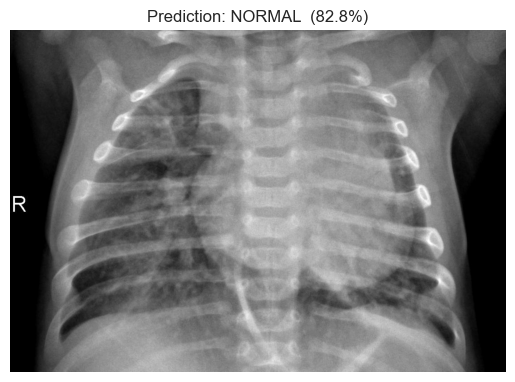

In [14]:
from src.prediction import predict, reset_model_cache
reset_model_cache()  # ensure we load the just-saved model

# Grab one real test image and predict it
sample = next((TEST_DIR / "PNEUMONIA").glob("*.jpeg"), None) or next((TEST_DIR / "PNEUMONIA").glob("*.jpg"))
result = predict(str(sample))
print("File:", sample.name)
print(json.dumps(result, indent=2))

plt.imshow(plt.imread(sample), cmap="gray")
plt.title(f"Prediction: {result['prediction']}  ({result['confidence']*100:.1f}%)")
plt.axis("off"); plt.show()

## 8 · Save the Model

Saved in both the native `.keras` format and legacy `.h5` (rubric-compatible),
into `models/`. This is the artifact the API loads in production.


In [15]:
from src.model import save_model
save_model(model)
print("Saved:")
for f in Path("../models").glob("pneumonia_model.*"):
    print(" ", f.name, f"({f.stat().st_size/1e6:.1f} MB)")

C:\Users\HP\Desktop\Summative final\pneumonia-detection-mlops\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved:
  pneumonia_model.h5 (10.4 MB)
  pneumonia_model.keras (10.6 MB)


## 9 · Retraining Function & Trigger

`src/model.retrain()` implements the retraining cycle used by the deployed **Retrain button**:
1. Merge user-uploaded images from `data/uploads/<class>/` into `data/train/<class>/`
2. Rebuild generators (now including the new data)
3. Train a fresh model → evaluate → save (overwriting the deployed model)

**Trigger:** in production this runs either (a) when a user clicks *Trigger Retraining* in the UI,
or (b) automatically once `RETRAIN_TRIGGER_THRESHOLD` new images have been uploaded (see `/upload`).

The cell below demonstrates the function (uses a few epochs for speed).


In [16]:
from src.model import retrain
# Demo: retrain for a couple of epochs. In production this is called by the API.
# result = retrain(model_type="mobilenet", epochs=3)
# print(json.dumps(result["new_metrics"], indent=2))
print("retrain() is ready — trigger it from the deployed UI or uncomment above to run here.")

retrain() is ready — trigger it from the deployed UI or uncomment above to run here.


---
## Summary

- Non-tabular image data (chest X-ray images)
- Detailed preprocessing (resize, RGB, rescale, augmentation, class weights)
- 3 interpreted feature visualisations
- Transfer-learning model with regularisation + early stopping
- Full evaluation metric suite (accuracy, loss, precision, recall, F1, AUC, confusion matrix)
- Single-image prediction function
- Saved `.keras` / `.h5` model
- Retraining function + trigger

The same `src/` modules power the **FastAPI + Docker deployment** and the **Locust flood test**
(see the project `README.md`).